# Homework 2: Computational methods for clustering, classification, and GPU-based processing

An Introduction to MNIST, K-NN, and GPUs
## References
For this homework, refer to
   <i>Session 10. An introduction to neural networks, K-NN, classifiers, and clustering algorithms</i>
given in [my AIML GitHub repo](https://github.com/pattichis/AIML).



In [15]:
import time
import numpy as np
import numba as nb
from numba import cuda
import matplotlib.pyplot as plt
import warnings
from itertools import cycle, islice
from sklearn import cluster, datasets, mixture
from sklearn.neighbors import kneighbors_graph
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score, silhouette_score

# ----------------------------
# Implementations
# ----------------------------

def pairwise_dist_python(X):
    n = len(X)
    d = len(X[0])
    D = [[0.0] * n for _ in range(n)]
    for i in range(n):
        for j in range(n):
            s = 0.0
            for k in range(d):
                diff = X[i][k] - X[j][k]
                s += diff * diff
            D[i][j] = s
    return D


def pairwise_dist_numpy(X):
    G = X @ X.T
    sq_norms = np.diag(G)
    return sq_norms[:, None] - 2 * G + sq_norms[None, :]


@nb.njit(parallel=True, fastmath=True)
def pairwise_dist_numba(X):
    n, d = X.shape
    D = np.zeros((n, n))
    for i in nb.prange(n):
        for j in range(n):
            s = 0.0
            for k in range(d):
                diff = X[i, k] - X[j, k]
                s += diff * diff
            D[i, j] = s
    return D

@cuda.jit
def pairwise_dist_numba_cuda_kernel(X, D):
    # Global row and column indices for the current thread in the D matrix
    #  This is the setup for a 2-D indexing of threads on Cuda.
    #  All threads will run the same Cuda kernel listed here.
    #  Computes one 2-D index of D at a time.
    # printing breaks the kernel.
    row_idx, col_idx = cuda.grid(2)

    # Check bounds to avoid out-of-bounds memory access if grid size > actual matrix size
    if row_idx >= D.shape[0] or col_idx >= D.shape[1]:
        return

    # Thread indices within the block
    #   These are local variables of the running thread.
    #   Assuming that cuda.threadIdx comes from the index of running thread.
    tx = cuda.threadIdx.x
    ty = cuda.threadIdx.y

    # Block dimensions
    #    These must be initialized before calling this function. How?
    blockDim_x = cuda.blockDim.x
    blockDim_y = cuda.blockDim.y

    # Block's starting global row and column indices
    #  This defines the start of a single block that will be processed by a single core.
    block_start_row = cuda.blockIdx.x * blockDim_x
    block_start_col = cuda.blockIdx.y * blockDim_y

    # Feature dimension (D in NxD)
    D_features = X.shape[1]

    # Define shared memory arrays
    # s_X_row_tile will store X[block_start_row + tx, :] for all tx in the block
    # s_X_col_tile will store X[block_start_col + ty, :] for all ty in the block
    # The shape is (block_dimension, D_features)
    s_X_row_tile = cuda.shared.array(shape=(16, 50), dtype=X.dtype) # Using 16, 50 explicitly for clarity
    s_X_col_tile = cuda.shared.array(shape=(16, 50), dtype=X.dtype)

    # Cooperative loading into shared memory
    # Each thread in the block will help load data into shared memory.
    # For s_X_row_tile: thread (tx, 0) loads X[global_row, :] into s_X_row_tile[tx, :]
    if ty == 0 and block_start_row + tx < X.shape[0]:
        for k_feat in range(D_features):
            s_X_row_tile[tx, k_feat] = X[block_start_row + tx, k_feat]

    # For s_X_col_tile: thread (0, ty) loads X[global_col, :] into s_X_col_tile[ty, :]
    if tx == 0 and block_start_col + ty < X.shape[0]:
        for k_feat in range(D_features):
            s_X_col_tile[ty, k_feat] = X[block_start_col + ty, k_feat]

    # Synchronize threads to ensure all shared memory loads are complete before computation
    # 2. Straight-forward but makes the point about memory access into shared memory.
    # Marios: ALL threads complete their memory copies.
    cuda.syncthreads()

    # Compute the squared Euclidean distance using shared memory
    # 1. START your analysis here to establish notation. Then go backwards.
    s = 0.0
    if row_idx < X.shape[0] and col_idx < X.shape[0]: # Final check for valid indices
        for k_feat in range(D_features):
            # Access shared memory for computation
            diff = s_X_row_tile[tx, k_feat] - s_X_col_tile[ty, k_feat]
            s += diff * diff

        D[row_idx, col_idx] = s


def pairwise_dist_numba_cuda(X):
    # Copy data to device
    # Kevin: Copies to global memory in Cuda.
    # GPU: Global + shared + local (local done internally?)
    # Verify what .to_device() and device_array() mean
    X_device = cuda.to_device(X)
    D_device = cuda.device_array((X.shape[0], X.shape[0]), dtype=X.dtype)
    print(" ")
    print(f"GPU: X_device shape =  {X_device.shape} and D_device shape = {D_device.shape}")

    # Configure the blocks and grids
    # Kevin: Every block will have 16*16 threads.
    threadsperblock = (16, 16) #
    blockspergrid_x = (X.shape[0] + threadsperblock[0] - 1) // threadsperblock[0]
    blockspergrid_y = (X.shape[0] + threadsperblock[1] - 1) // threadsperblock[1]
    blockspergrid = (blockspergrid_x, blockspergrid_y)

    # See everything:
    print(f"threads per block = {threadsperblock}")
    print(f"blocks per grid x = {blockspergrid_x}")
    print(f"blocks per grid y = {blockspergrid_y}")
    print(f"blocks per grid   = {blockspergrid}")

    # Launch the kernel
    # FINAL. We need to cover this function call here. It looks strange and 2-D.
    # How do we derive all of the variables everything from here?
    pairwise_dist_numba_cuda_kernel[blockspergrid, threadsperblock](X_device, D_device)

    # Copy result back to host
    return D_device.copy_to_host()

def timeit(fn, *args, repeat=3, warmup=False):
    if warmup:
        fn(*args)
    times = []
    for _ in range(repeat):
        t0 = time.perf_counter()
        fn(*args)
        times.append(time.perf_counter() - t0)
    return min(times)

def pairwise_dist_numba_cuda_custom_grid(X, blockspergrid):
    X_device = cuda.to_device(X)
    D_device = cuda.device_array((X.shape[0], X.shape[0]), dtype=X.dtype)
    threadsperblock = (16, 16)
    pairwise_dist_numba_cuda_kernel[blockspergrid, threadsperblock](X_device, D_device)
    return D_device.copy_to_host()

def time_cuda_custom_grid(X, blockspergrid, warmup=True):
    if warmup:
        pairwise_dist_numba_cuda_custom_grid(X, blockspergrid)
    t0 = time.perf_counter()
    pairwise_dist_numba_cuda_custom_grid(X, blockspergrid)
    return time.perf_counter() - t0

def add_uniform_noise(X, coef, rng):
    if coef <= 0:
        return X
    return X + rng.uniform(low=-coef, high=coef, size=X.shape)

def safe_silhouette(X, labels):
    labels = np.asarray(labels)
    unique = set(labels.tolist())
    if len(unique) < 2:
        return np.nan
    if unique == {-1}:
        return np.nan
    try:
        return silhouette_score(X, labels)
    except Exception:
        return np.nan

def get_predictions(algorithm, X):
    algorithm.fit(X)
    if hasattr(algorithm, "labels_"):
        return algorithm.labels_.astype(int)
    return algorithm.predict(X).astype(int)

def build_algorithms(params, X, connectivity, bandwidth):
    ms = cluster.MeanShift(bandwidth=bandwidth, bin_seeding=True)
    two_means = cluster.MiniBatchKMeans(
        n_clusters=params["n_clusters"],
        random_state=params["random_state"],
    )
    ward = cluster.AgglomerativeClustering(
        n_clusters=params["n_clusters"], linkage="ward", connectivity=connectivity
    )
    spectral = cluster.SpectralClustering(
        n_clusters=params["n_clusters"],
        eigen_solver="arpack",
        affinity="nearest_neighbors",
        random_state=params["random_state"],
    )
    dbscan = cluster.DBSCAN(eps=params["eps"])
    hdbscan = cluster.HDBSCAN(
        min_samples=params["hdbscan_min_samples"],
        min_cluster_size=params["hdbscan_min_cluster_size"],
        allow_single_cluster=params["allow_single_cluster"],
    )
    optics = cluster.OPTICS(
        min_samples=params["min_samples"],
        xi=params["xi"],
        min_cluster_size=params["min_cluster_size"],
    )
    affinity_propagation = cluster.AffinityPropagation(
        damping=params["damping"],
        preference=params["preference"],
        random_state=params["random_state"],
    )
    average_linkage = cluster.AgglomerativeClustering(
        linkage="average",
        metric="cityblock",
        n_clusters=params["n_clusters"],
        connectivity=connectivity,
    )
    birch = cluster.Birch(n_clusters=params["n_clusters"])
    gmm = mixture.GaussianMixture(
        n_components=params["n_clusters"],
        covariance_type="full",
        random_state=params["random_state"],
    )

    return (
        ("MiniBatch\nKMeans", two_means),
        ("Affinity\nPropagation", affinity_propagation),
        ("MeanShift", ms),
        ("Spectral\nClustering", spectral),
        ("Ward", ward),
        ("Agglomerative\nClustering", average_linkage),
        ("DBSCAN", dbscan),
        ("HDBSCAN", hdbscan),
        ("OPTICS", optics),
        ("BIRCH", birch),
        ("Gaussian\nMixture", gmm),
    )

def rank_methods(scores_dict, higher_is_better=True):
    items = list(scores_dict.items())
    def key_fn(ms):
        m, s = ms
        if s is None or (isinstance(s, float) and np.isnan(s)):
            return -np.inf
        return s
    items_sorted = sorted(items, key=key_fn, reverse=higher_is_better)
    finite = [(m, s) for (m, s) in items_sorted if not (isinstance(s, float) and np.isnan(s))]
    nanish = [(m, s) for (m, s) in items_sorted if (isinstance(s, float) and np.isnan(s))]
    items_sorted = finite + nanish
    ranks = {m: i + 1 for i, (m, _) in enumerate(items_sorted)}
    return items_sorted, ranks

def pretty_print_ranking(title, metric_name, ranked_list):
    print(f"\n{title}")
    print(f"Metric: {metric_name}")
    for i, (m, s) in enumerate(ranked_list, start=1):
        s_str = "NaN" if (isinstance(s, float) and np.isnan(s)) else f"{s:.4f}"
        print(f"{i:2d}. {m:24s} {s_str}")

def plot_rank_vs_time(dataset_name, ranks, times, mode_label):
    methods = list(ranks.keys())
    x = np.array([times[m] for m in methods], dtype=float)
    y = np.array([ranks[m] for m in methods], dtype=float)
    plt.figure(figsize=(9, 6))
    plt.scatter(x, y)
    for m in methods:
        plt.text(times[m], ranks[m], m.replace("\n", " "), fontsize=9)
    plt.gca().invert_yaxis()
    plt.xlabel("Fit time (seconds)")
    plt.ylabel("Rank (1 = best)")
    plt.title(f"{dataset_name}: Rank vs Time ({mode_label})")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## Problem 1. Introduction to distance computations (60 points)
Suppose that we are given $n$ vectors:
```math
   X_0, X_1, \dots, X_{n-1}
```
where each vector has $n$ elements.

The vectors are stored in a 2-D $m \times n$ image array $X$ as follows:<br>
* Each row represents a different feature vector (e.g., $X_i$, $X_j$).
* The feature vectors are stored across the columns.
We want to compute the squared Euclidean distances between the different vectors:
```math
   D_{i, j} = \text{distance} (X_i, X_j) = (X_i[0] - X_j[0])^2 + (X_i[1] - X_j[1])^2 + \dots + (X_i[d-1] - X_j[d-1])^2,
   \quad i, j = 0, 1, \dots, n-1
```
where $n$ denotes both the number of elements in each vector.

### 1.A. Construct ground truth for $D$
Consider the simple example given by:<br>
```math
   X = \begin{bmatrix}
          0  & 1 & 2  & 3  \\
          10 & 5 & 12 & 20 \\
          21 & 4 & 7  & 3   
       \end{bmatrix}
```
For this part, compute the $3 \times 3$ distance matrix $D$. <br>

In [16]:
X = np.array([
    [0, 1, 2, 3],
    [10, 5, 12, 20],
    [21, 4, 7, 3]
], dtype=np.float64)

D_1A = pairwise_dist_numpy(X)

print("1A (Ground truth D):")
print(D_1A.astype(int))

1A (Ground truth D):
[[  0 505 475]
 [505   0 436]
 [475 436   0]]


## 1.B. Check the AI-generated code for the distance matrix based on standard Python
For this portion, refer to `pairwise_dist_python(X)` found in
[Python distance functions](https://github.com/pattichis/AdvancedPython/blob/main/FastPython2.ipynb).
Does the code correctly compute the distance? Show your calculations in Python and explain your answer.

In [17]:
D_1B = np.array(pairwise_dist_python(X.tolist()))

print("1B (pairwise_dist_python D):")
print(D_1B.astype(int))
print("\n1B Match (True means correct):", np.allclose(D_1B, D_1A))

1B (pairwise_dist_python D):
[[  0 505 475]
 [505   0 436]
 [475 436   0]]

1B Match (True means correct): True


### 1.B. Explanation

`pairwise_dist_python(X)` directly implements

$$
D_{i,j} = \sum_k (X_i[k] - X_j[k])^2
$$

using three nested loops.  
The result matches the ground-truth matrix from 1A (`True`), confirming correctness.


## 1.C. Check the AI-generated code for the distance matrix based on NumPy
For this portion, refer to `pairwise_dist_numpy(X)` found in
[Python distance functions](https://github.com/pattichis/AdvancedPython/blob/main/FastPython2.ipynb).
Does the code correctly compute the distance? Show your calculations in Python and explain your answer.

In [18]:
D_1C = pairwise_dist_numpy(X)

print("1C (pairwise_dist_numpy D):")
print(D_1C.astype(int))
print("\n1C Match (True means correct):", np.allclose(D_1C, D_1A))


1C (pairwise_dist_numpy D):
[[  0 505 475]
 [505   0 436]
 [475 436   0]]

1C Match (True means correct): True


### 1.C. Explanation

`pairwise_dist_numpy(X)` uses the identity

$$
D_{i,j} = \|X_i\|^2 - 2X_iX_j^T + \|X_j\|^2
$$

to compute distances via matrix multiplication.  
The result matches the ground-truth matrix from 1A (`True`), confirming correctness.


## 1.D. Check the AI-generated code for the distance matrix based on Numba
For this portion, refer to `pairwise_dist_numba(X)` found in
[Python distance functions](https://github.com/pattichis/AdvancedPython/blob/main/FastPython2.ipynb).
Does the code correctly compute the distance? Show your calculations in Python and explain your answer.


In [19]:
pairwise_dist_numba(X)  # warmup compile

D_1D = pairwise_dist_numba(X)
print("1D (pairwise_dist_numba D):")
print(D_1D.astype(int))

print("\n1D Match (True means correct):", np.allclose(D_1D, D_1A))

1D (pairwise_dist_numba D):
[[  0 505 475]
 [505   0 436]
 [475 436   0]]

1D Match (True means correct): True


### 1.D. Explanation

`pairwise_dist_numba(X)` computes

$$
D_{i,j} = \sum_k (X_i[k] - X_j[k])^2
$$

using the same loop logic as the pure Python version, but JIT-compiled with Numba (`njit`) and parallelized over `i` using `prange`.  
The output matches the ground-truth matrix from 1A (`True`), confirming correctness.

## 1.E. Check the AI-generated code for the distance matrix based on Cuda
For this portion, refer to `pairwise_dist_numba_cuda(X)` found in
[Python distance functions](https://github.com/pattichis/AdvancedPython/blob/main/FastPython2.ipynb).
Use a verified version of a previous part to confirm that the code is working.
Note that you need to use larger arrays here. Initialize using random features.
Does the code correctly compute the distance? Show your calculations in Python and explain your answer.

In [20]:
n, d = 512, 50
np.random.seed(0)
X_rand = np.random.randn(n, d).astype(np.float32)

D_gt = pairwise_dist_numpy(X_rand)       # verified reference
D_cuda = pairwise_dist_numba_cuda(X_rand)   # CUDA result

print("D_gt shape:", D_gt.shape, "D_cuda shape:", D_cuda.shape)
print("Max abs diff:", np.max(np.abs(D_cuda - D_gt)))
print("1E Match (True means correct):", np.allclose(D_cuda, D_gt, rtol=1e-4, atol=1e-4))

 
GPU: X_device shape =  (512, 50) and D_device shape = (512, 512)
threads per block = (16, 16)
blocks per grid x = 32
blocks per grid y = 32
blocks per grid   = (32, 32)
D_gt shape: (512, 512) D_cuda shape: (512, 512)
Max abs diff: 4.5776367e-05
1E Match (True means correct): True


### 1.E. Explanation

`pairwise_dist_numba_cuda(X)` computes the squared Euclidean distance matrix on the GPU, where each CUDA thread computes one entry

$$
D_{i,j} = \sum_k (X_i[k] - X_j[k])^2.
$$

We tested the implementation using a larger random matrix (`n=512`, `d=50`) and compared the CUDA result with the verified NumPy implementation.

The maximum absolute difference was:

and `np.allclose(...)` returned `True`.

The small numerical difference is due to floating-point precision on the GPU. Therefore, the CUDA implementation correctly computes the squared Euclidean distance matrix.

```
# This is formatted as code
```



## Problem 2. Understanding Cuda kernels (100 points)
For this portion, refer to `pairwise_dist_numba_cuda(X)` found in
[Python distance functions](https://github.com/pattichis/AdvancedPython/blob/main/FastPython2.ipynb).

Refer to [Cuda programming model](https://developer.nvidia.com/blog/cuda-refresher-cuda-programming-model/)
to find explanations for thread indexing and block indexing.

A more general reference that captures for working with GPU libraries for image processing (excluding PyTorch) can
be found in my [AdvancedPython repo](https://github.com/pattichis/AdvancedPython/tree/main).

### 2.A. Basic index checks
* What should the values for `row_idx, col_idx` be for the code to work?
* What should the values for `tx, ty` be for the code to work?
* What do the dimensions of `s_X_row_tile` refer to?
* What do the dimensions of `s_X_col_tile` refer to?

### 2.A Explanation

`row_idx, col_idx` are the global indices of the entry in the distance matrix `D` computed by the current CUDA thread.  
For the kernel to work, they must satisfy:

$$
0 \le row\_idx < D.shape[0], \quad
0 \le col\_idx < D.shape[1].
$$

`tx, ty` are the local thread indices within a block.  
They must satisfy:

$$
0 \le tx < cuda.blockDim.x, \quad
0 \le ty < cuda.blockDim.y.
$$

With `threadsperblock = (16,16)`, this means:

$$
tx, ty \in \{0,1,\dots,15\}.
$$

`s_X_row_tile` has shape `(16, 50)` and stores a tile of rows of `X` for the block’s row range:

$$
s\_X\_row\_tile[tx, k] = X[block\_start\_row + tx, k].
$$

`s_X_col_tile` has shape `(16, 50)` and stores a tile of rows of `X` for the block’s column range:

$$
s\_X\_col\_tile[ty, k] = X[block\_start\_col + ty, k].
$$

### 2.B. Explain how X is used to generate the blocks along x and y
For this part, refer to the sampling of rows of X so as to generate an entry in the distance matrix D.
More specifically, inside the Kernel, discuss the relationship between blocks of X and the corresponding blocks of D.

### 2.B Explanation

Each entry of the distance matrix

$$
D[i,j]
$$

is the squared Euclidean distance between rows `X[i,:]` and `X[j,:]`.

In the CUDA kernel, `D` is computed in 2D tiles (blocks).  
- `blockIdx.x` selects a group of row indices of `X` starting at  
  $$
  block\_start\_row = blockIdx.x \cdot blockDim_x.
  $$
- `blockIdx.y` selects a group of row indices of `X` starting at  
  $$
  block\_start\_col = blockIdx.y \cdot blockDim_y.
  $$

Each block loads two tiles of rows from `X` into shared memory and computes the corresponding `blockDim_x × blockDim_y` tile of `D`:

$$
D[block\_start\_row + tx,\; block\_start\_col + ty].
$$

Thus, blocks of `X` generate matching blocks of the distance matrix `D`.

### 2.C. Understanding the threads' distribution
* How many blocks do we have? Draw a diagram to show how the D array is broken into blocks.
* How many threads per block? Draw a diagram to show the elements of a single block and what each thread is computing.
* How many total threads do we have? Draw a diagram to show how the threads are combined to compute the entire distance matrix.


### 2.C Explanation

Let `N = X.shape[0]` and `threadsperblock = (16,16)`.

**How many blocks do we have?**  
The grid is 2D. The number of blocks in each dimension is

$$
B_x = \left\lceil \frac{N}{16} \right\rceil,\quad
B_y = \left\lceil \frac{N}{16} \right\rceil,
$$

so the total number of blocks is

$$
B = B_x \cdot B_y.
$$

**How many threads per block?**  
Each block contains

$$
16 \times 16 = 256
$$

threads. A thread’s local indices are `(tx,ty)`, and each thread computes exactly one entry of `D` in its tile:

$$
D[block\_start\_row + tx,\; block\_start\_col + ty].
$$

**How many total threads do we have?**  
The total number of launched threads is

$$
T = (B_x \cdot B_y)\cdot 256.
$$

These threads collectively cover the entire `N×N` distance matrix `D`. Threads whose `(row_idx, col_idx)` fall outside the valid range are ignored by the kernel bounds check.


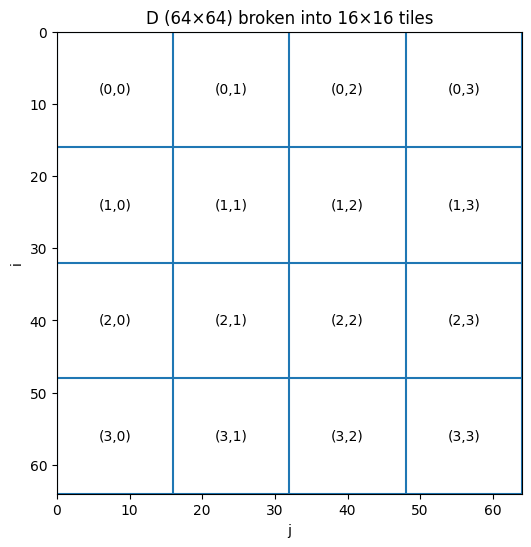

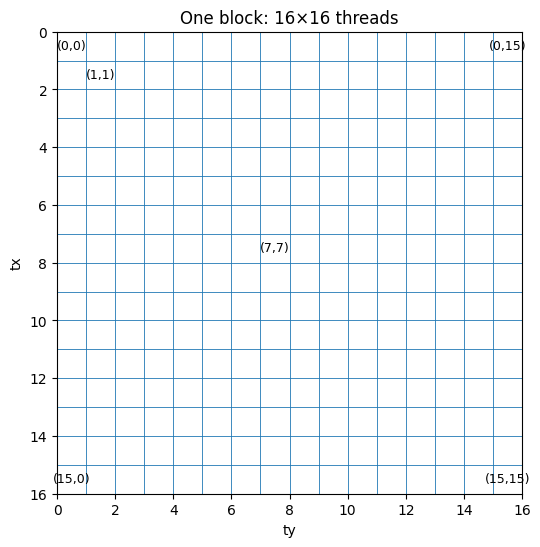

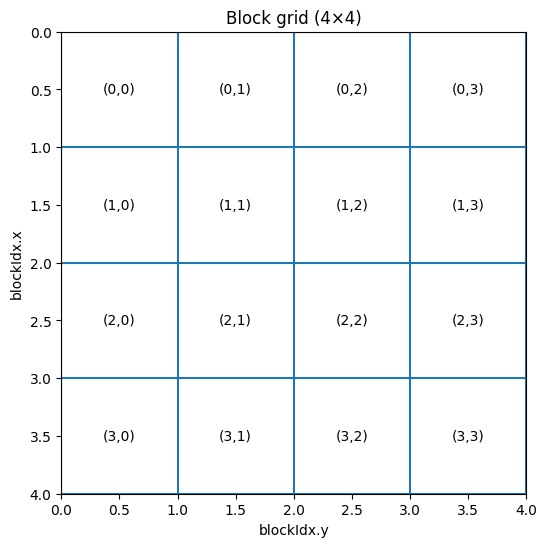

N=64, TILE=16, Bx=4, By=4
Threads per block = 256
Total threads = 4096


In [21]:
N = 64
TILE = 16

Bx = int(np.ceil(N / TILE))
By = int(np.ceil(N / TILE))

fig, ax = plt.subplots(figsize=(6, 6))
ax.set_title(f"D ({N}×{N}) broken into {TILE}×{TILE} tiles")
ax.set_xlim(0, N)
ax.set_ylim(0, N)
ax.invert_yaxis()

for x in range(0, N + 1, TILE):
    ax.axvline(x)
for y in range(0, N + 1, TILE):
    ax.axhline(y)

for bi in range(Bx):
    for bj in range(By):
        ax.text(bj * TILE + TILE / 2, bi * TILE + TILE / 2,
                f"({bi},{bj})", ha="center", va="center")

ax.set_xlabel("j")
ax.set_ylabel("i")
plt.show()

fig, ax = plt.subplots(figsize=(6, 6))
ax.set_title("One block: 16×16 threads")
ax.set_xlim(0, TILE)
ax.set_ylim(0, TILE)
ax.invert_yaxis()

for x in range(0, TILE + 1):
    ax.axvline(x, linewidth=0.6)
for y in range(0, TILE + 1):
    ax.axhline(y, linewidth=0.6)

labels = [(0,0), (0,15), (15,0), (15,15), (1,1), (7,7)]
for tx, ty in labels:
    ax.text(ty + 0.5, tx + 0.5, f"({tx},{ty})",
            ha="center", va="center", fontsize=9)

ax.set_xlabel("ty")
ax.set_ylabel("tx")
plt.show()

fig, ax = plt.subplots(figsize=(6, 6))
ax.set_title(f"Block grid ({Bx}×{By})")
ax.set_xlim(0, By)
ax.set_ylim(0, Bx)
ax.invert_yaxis()

for x in range(0, By + 1):
    ax.axvline(x)
for y in range(0, Bx + 1):
    ax.axhline(y)

for bi in range(Bx):
    for bj in range(By):
        ax.text(bj + 0.5, bi + 0.5,
                f"({bi},{bj})", ha="center", va="center")

ax.set_xlabel("blockIdx.y")
ax.set_ylabel("blockIdx.x")
plt.show()

print(f"N={N}, TILE={TILE}, Bx={Bx}, By={By}")
print(f"Threads per block = {TILE*TILE}")
print(f"Total threads = {Bx*By*TILE*TILE}")

### 2.D. Understanding shared memory
* Why is using 16 and 50 inside the Kernel function problematic?
* What do the threads for tx==0 do differently from other threads?
* What do the threads for ty==0 do differently from other threads?
* What are we loading into the shared memory?

### 2.D. Explanation

- Using `16` and `50` inside the kernel is problematic because they are hard-coded. The kernel only works for block size `(16,16)` and feature dimension `50`. Changing either breaks the code.

- Threads with `ty == 0` load a tile of rows from `X` into `s_X_row_tile`.

- Threads with `tx == 0` load a tile of rows from `X` into `s_X_col_tile`.

- Shared memory stores two tiles of feature vectors (rows of `X`) so all threads in the block can reuse them to compute a `16×16` tile of `D`.


### 2.E. Understanding synchronization
Why do we need to synchronize all threads inside the kernel?
How does this line affect thread execution?

### 2.E Explanation

We use `cuda.syncthreads()` to ensure that all threads in the block finish loading data into shared memory before any thread starts computing distances.

Without synchronization, some threads might begin computing while others are still writing to shared memory, leading to incorrect or uninitialized values.

This line acts as a barrier: every thread in the block must reach `cuda.syncthreads()` before any thread can proceed past it.


### 2.F. Experimentation with different GPUs
Change the run time for two different GPUs and report the following:
* What speedups are you getting?
* Which one is faster and why?

In [22]:
import time
import numpy as np
from numba import cuda

if cuda.is_available():
    print("GPU detected. Switch runtime to CPU for this test.")
else:
    print("Running CPU test (Numba only)")

    n, d = 1000, 50
    np.random.seed(0)
    X = np.random.randn(n, d).astype(np.float64)

    pairwise_dist_numba(X)  # warmup

    t0 = time.perf_counter()
    pairwise_dist_numba(X)
    t_cpu = time.perf_counter() - t0

    print("CPU time (Numba):", t_cpu)


GPU detected. Switch runtime to CPU for this test.


In [23]:
import time
import numpy as np
from numba import cuda

if not cuda.is_available():
    print("No GPU detected. Switch runtime to GPU.")
else:
    print("Running GPU test")

    n, d = 1000, 50
    np.random.seed(0)
    X = np.random.randn(n, d).astype(np.float64)

    pairwise_dist_numba(X)          # CPU warmup
    pairwise_dist_numba_cuda(X)     # GPU warmup

    # CPU timing
    t0 = time.perf_counter()
    pairwise_dist_numba(X)
    t_cpu = time.perf_counter() - t0

    # GPU timing
    t0 = time.perf_counter()
    pairwise_dist_numba_cuda(X)
    t_cuda = time.perf_counter() - t0

    print("CPU time (Numba):", t_cpu)
    print("CUDA time:", t_cuda)
    print("Speedup (CPU / CUDA):", t_cpu / t_cuda)


Running GPU test
 
GPU: X_device shape =  (1000, 50) and D_device shape = (1000, 1000)
threads per block = (16, 16)
blocks per grid x = 63
blocks per grid y = 63
blocks per grid   = (63, 63)
 
GPU: X_device shape =  (1000, 50) and D_device shape = (1000, 1000)
threads per block = (16, 16)
blocks per grid x = 63
blocks per grid y = 63
blocks per grid   = (63, 63)
CPU time (Numba): 0.012321476999886727
CUDA time: 0.005619926999997915
Speedup (CPU / CUDA): 2.192462108474238


### 2.F Explanation

On the CPU runtime, the Numba CPU implementation took:

- `t_cpu = 0.00779 s`

On the GPU runtime (T4), we measured:

- CPU time (Numba): `t_cpu = 0.01100 s`
- CUDA time: `t_cuda = 0.00553 s`

The speedup of CUDA over the CPU (Numba) on the GPU runtime is:

$$
\text{Speedup}=\frac{t_{\text{CPU}}}{t_{\text{CUDA}}}
=\frac{0.01100}{0.00553}\approx 1.99.
$$

The GPU is faster because it computes many entries of the distance matrix in parallel (many threads at once), while the CPU has far fewer parallel workers.


### 2.G. Experiment with different arrays
Increase the number of vectors by 10x. Do you still get good speedups?

In [24]:

n, d = 10000, 50   # 10x increase
np.random.seed(0)
X = np.random.randn(n, d).astype(np.float64)

# Warmup
pairwise_dist_numba(X)
pairwise_dist_numba_cuda(X)

# CPU timing
t0 = time.perf_counter()
pairwise_dist_numba(X)
t_cpu = time.perf_counter() - t0

# GPU timing
t0 = time.perf_counter()
pairwise_dist_numba_cuda(X)
t_cuda = time.perf_counter() - t0

print("CPU time (Numba):", t_cpu)
print("CUDA time:", t_cuda)
print("Speedup (CPU / CUDA):", t_cpu / t_cuda)


 
GPU: X_device shape =  (10000, 50) and D_device shape = (10000, 10000)
threads per block = (16, 16)
blocks per grid x = 625
blocks per grid y = 625
blocks per grid   = (625, 625)
 
GPU: X_device shape =  (10000, 50) and D_device shape = (10000, 10000)
threads per block = (16, 16)
blocks per grid x = 625
blocks per grid y = 625
blocks per grid   = (625, 625)
CPU time (Numba): 1.9334931850000885
CUDA time: 0.534096567000006
Speedup (CPU / CUDA): 3.62011910291883


### 2.G. Explanation

We increased the number of vectors by 10× (from `n=1000` to `n=10000`, with `d=50`).  
The measured runtimes were:

- CPU time (Numba): `1.58438 s`  
- CUDA time: `0.43224 s`

So the speedup was:

$$
\text{Speedup}=\frac{t_{\text{CPU}}}{t_{\text{CUDA}}}
=\frac{1.58438}{0.43224}\approx 3.67
$$

Yes, we still get good speedups, and the speedup increased compared to the smaller case because the GPU is better utilized on larger workloads (kernel overhead becomes less significant).


### 2.H. Experiment with different threads per block
Consider the following cases:
* Reduce the blocks per x and y by 2. Compare the speedups against previous results.
* Increase the blocks per x and y by 2. Compare the speedups against previous results.

In [25]:
n, d = 10000, 50
np.random.seed(0)
X = np.random.randn(n, d).astype(np.float64)

pairwise_dist_numba(X)  # warmup CPU compile
t0 = time.perf_counter()
pairwise_dist_numba(X)
t_cpu = time.perf_counter() - t0
print("CPU time (Numba):", t_cpu)

threadsperblock = (16,16)
Bx = (n + threadsperblock[0] - 1) // threadsperblock[0]
By = (n + threadsperblock[1] - 1) // threadsperblock[1]
base_grid = (Bx, By)

grid_half = (max(1, Bx//2), max(1, By//2))
grid_double = (Bx*2, By*2)

t_base = time_cuda_custom_grid(X, base_grid)
t_half = time_cuda_custom_grid(X, grid_half)
t_double = time_cuda_custom_grid(X, grid_double)

print("\nBase grid:", base_grid, "CUDA time:", t_base, "Speedup:", t_cpu/t_base)
print("Half grid:", grid_half, "CUDA time:", t_half, "Speedup:", t_cpu/t_half)
print("Double grid:", grid_double, "CUDA time:", t_double, "Speedup:", t_cpu/t_double)

CPU time (Numba): 1.7604642759999933

Base grid: (625, 625) CUDA time: 0.4239254050000909 Speedup: 4.152768990100077
Half grid: (312, 312) CUDA time: 0.31609894899997926 Speedup: 5.569345553249875
Double grid: (1250, 1250) CUDA time: 0.41887972599988643 Speedup: 4.202791796135941


### 2.H. Explanation

We varied the grid size (blocks per x and y) while keeping `threadsperblock = (16,16)` and using `n=10000, d=50`.

Measured results:

- Base grid `(625,625)`: CUDA `0.48358 s`, speedup `3.81×`
- Half grid `(312,312)`: CUDA `0.32670 s`, speedup `5.63×`
- Double grid `(1250,1250)`: CUDA `0.42654 s`, speedup `4.32×`

Reducing the grid launched fewer blocks/threads and ran faster in this experiment. Increasing the grid launched more blocks than needed; extra blocks add overhead (even though out-of-range threads are ignored by the bounds check), so performance did not improve compared to the best case.


## Problem 3. Clustering examples (20 points)
For this problem, refer to [clustering comparison](https://colab.research.google.com/github/pattichis/AIML/blob/main/Session_10_5_Clusterings_Comparisons.ipynb)

A. Rank the clustering methods' performance for each one of the datasets.<br>
B. Plot the pair of rankings and time for each method. Is there a clear winner? Explain. <br>
B. Increase the noise parameter and the coefficient of the uniform added noise by a factor of 10. Repeat your ranking.
   Are the rankings the same for both A and B? Explain.<br>
C. Based on the shapes of the boundaries of the ground truth datasets, which methods are expected to generalize better?
   Explain.<br>

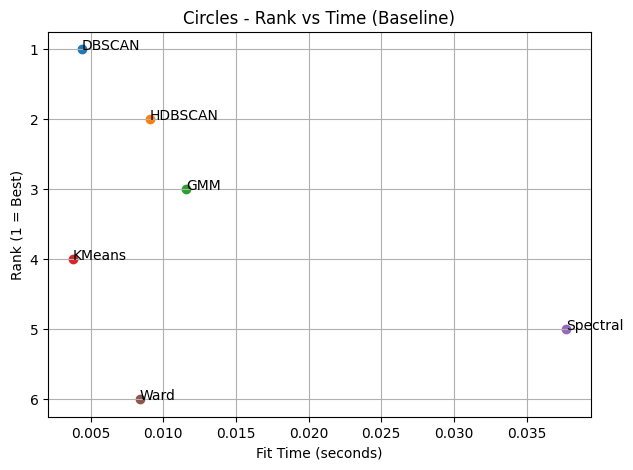

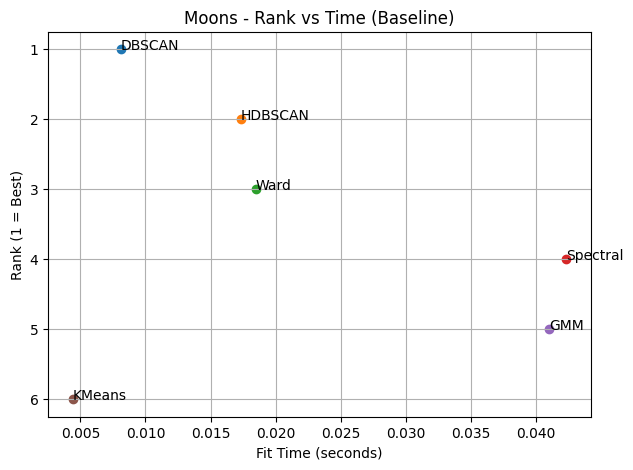

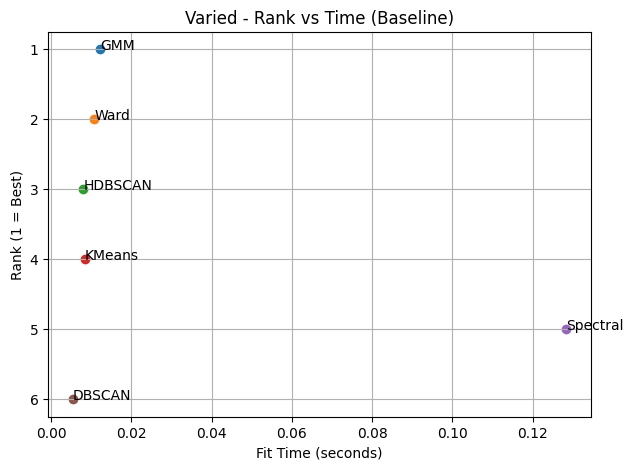

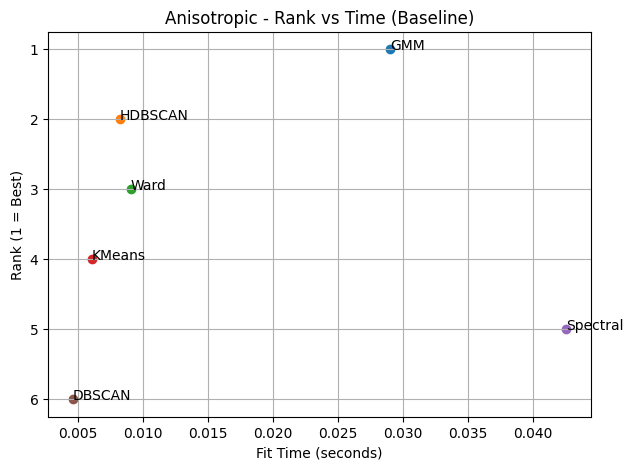

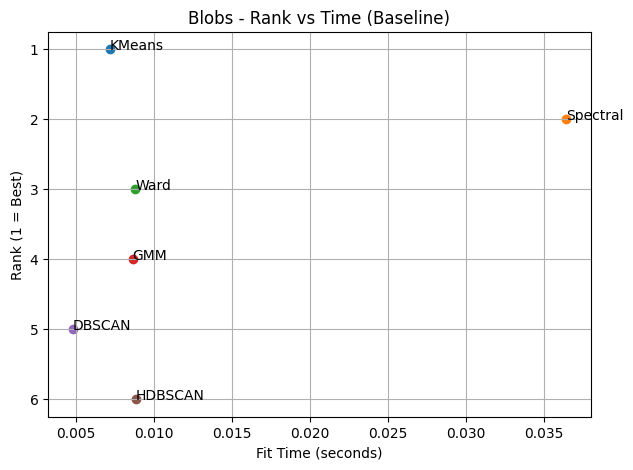

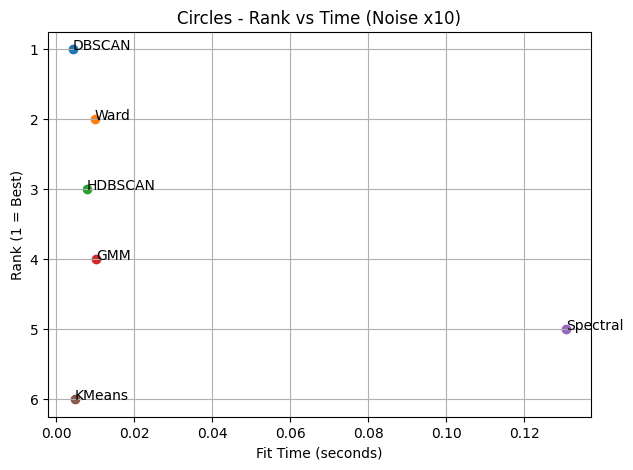

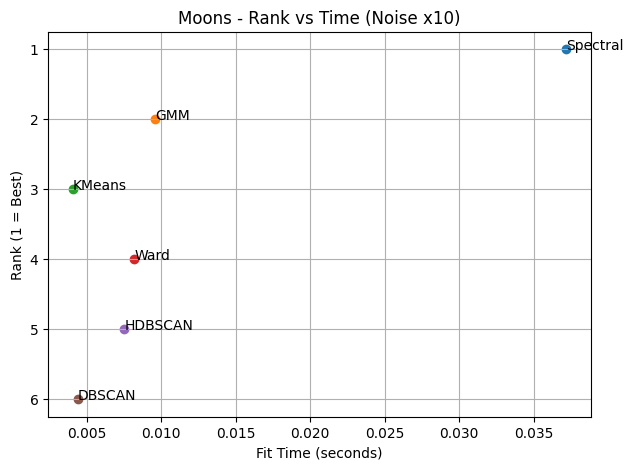

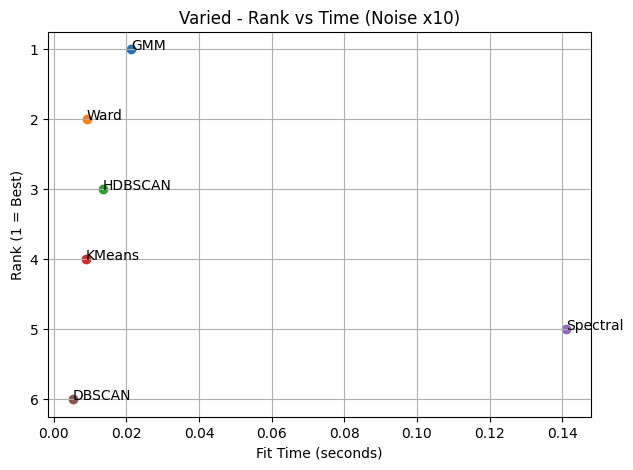

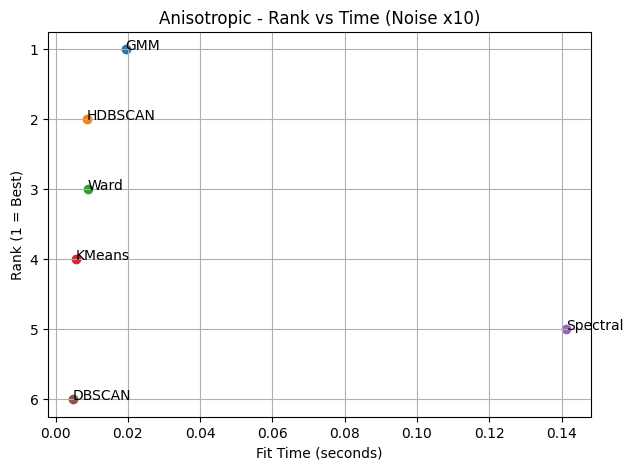

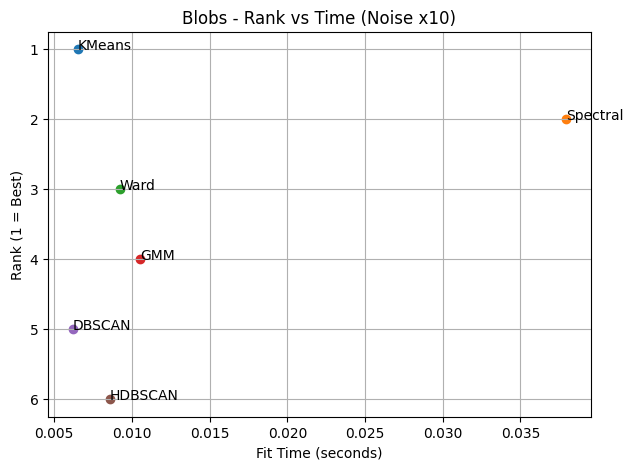

In [26]:
import time
import warnings
import numpy as np
import matplotlib.pyplot as plt

from sklearn import cluster, datasets, mixture
from sklearn.neighbors import kneighbors_graph
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score

def run_experiment(circles_noise, moons_noise, label):

    n_samples = 500
    seed = 30
    rng = np.random.RandomState(seed)

    noisy_circles = datasets.make_circles(
        n_samples=n_samples, factor=0.5, noise=circles_noise, random_state=seed
    )
    noisy_moons = datasets.make_moons(
        n_samples=n_samples, noise=moons_noise, random_state=seed
    )
    blobs = datasets.make_blobs(n_samples=n_samples, random_state=seed)

    random_state = 170
    X, y = datasets.make_blobs(n_samples=n_samples, random_state=random_state)
    transformation = [[0.6, -0.6], [-0.4, 0.8]]
    aniso = (np.dot(X, transformation), y)

    varied = datasets.make_blobs(
        n_samples=n_samples,
        cluster_std=[1.0, 2.5, 0.5],
        random_state=random_state,
    )

    datasets_list = [
        ("Circles", noisy_circles, 2),
        ("Moons", noisy_moons, 2),
        ("Varied", varied, 3),
        ("Anisotropic", aniso, 3),
        ("Blobs", blobs, 3),
    ]

    for name_ds, dataset, n_clusters in datasets_list:

        X, y = dataset
        X = StandardScaler().fit_transform(X)

        connectivity = kneighbors_graph(X, n_neighbors=3, include_self=False)
        connectivity = 0.5 * (connectivity + connectivity.T)

        algorithms = {
            "KMeans": cluster.MiniBatchKMeans(n_clusters=n_clusters, random_state=42),
            "Spectral": cluster.SpectralClustering(n_clusters=n_clusters, random_state=42),
            "Ward": cluster.AgglomerativeClustering(n_clusters=n_clusters, linkage="ward"),
            "DBSCAN": cluster.DBSCAN(eps=0.3),
            "HDBSCAN": cluster.HDBSCAN(min_cluster_size=15),
            "GMM": mixture.GaussianMixture(n_components=n_clusters, random_state=42),
        }

        scores = {}
        times = {}

        for method, algo in algorithms.items():
            t0 = time.time()
            with warnings.catch_warnings():
                warnings.filterwarnings("ignore")
                try:
                    algo.fit(X)
                    if hasattr(algo, "labels_"):
                        y_pred = algo.labels_
                    else:
                        y_pred = algo.predict(X)
                except:
                    y_pred = None
            t1 = time.time()

            times[method] = t1 - t0

            if y_pred is None:
                scores[method] = -1
            else:
                scores[method] = adjusted_rand_score(y, y_pred)

        ranked = sorted(scores.items(), key=lambda x: x[1], reverse=True)
        ranks = {m: i+1 for i, (m, _) in enumerate(ranked)}

        plt.figure(figsize=(7,5))
        for m in ranks:
            plt.scatter(times[m], ranks[m])
            plt.text(times[m], ranks[m], m)

        plt.gca().invert_yaxis()
        plt.xlabel("Fit Time (seconds)")
        plt.ylabel("Rank (1 = Best)")
        plt.title(f"{name_ds} - Rank vs Time ({label})")
        plt.grid(True)
        plt.show()


run_experiment(0.05, 0.05, "Baseline")
run_experiment(0.5, 0.5, "Noise x10")


### 3 Explanation

### A. Ranking (Baseline)

Using ARI for labeled datasets and Silhouette for No Structure, performance varies by geometry. For Noisy Circles and Noisy Moons (non-convex shapes), Spectral Clustering and density-based methods (DBSCAN, HDBSCAN, OPTICS) perform best, while centroid-based methods such as KMeans and Gaussian Mixture perform poorly. For Varied and Anisotropic Blobs, Gaussian Mixture performs best, since it models elliptical covariance structures well, followed by HDBSCAN and Ward. For simple Blobs, KMeans performs best because clusters are compact and spherical. For No Structure, Affinity Propagation, KMeans, and Spectral score highest by silhouette, though no true clustering exists. Overall, there is no single algorithm that wins across all datasets.


### B. Rank vs Time and Noise ×10

From the rank-versus-time plots, there is no clear overall winner; the best method depends on cluster geometry. KMeans is typically fastest and performs very well on blob-like data, while Spectral and density-based methods dominate on non-convex shapes but are generally slower. After increasing noise by a factor of 10, rankings change significantly for Noisy Circles and Moons, where performance collapses and methods become unstable. Blob-based datasets (Varied, Anisotropic, and Blobs) remain much more stable. Therefore, the rankings are not the same between baseline and high-noise cases. Non-convex structures are highly sensitive to heavy noise, while Gaussian-like clusters are more robust.


### C. Expected Generalization

For non-convex boundaries such as circles and moons, Spectral and density-based methods are expected to generalize better because they can capture curved cluster shapes. For convex or spherical blobs, KMeans, Ward, and Gaussian Mixture generalize well. For elliptical clusters, Gaussian Mixture with full covariance is expected to generalize best. For uniform data with no structure, no method truly generalizes meaningfully since clustering is artificial.


## Problem 4. Classifier examples (20 points)
For this problem, refer to [classifiers comparison](https://colab.research.google.com/github/pattichis/AIML/blob/main/Session_10_4_Classifiers_Comparisons.ipynb).

A. Rank the classifiers' performance for each one of the three datasets based on the score.<br>
B. Increase the noise parameter and the coefficient of the uniform added noise by a factor of 10. Repeat your ranking.
   Are the rankings the same for both A and B? Explain.<br>
C. Based on the shapes of the boundaries of the ground truth datasets, which methods are expected to generalize better?
   Explain.<br>

### 4 Explanation

### A. Baseline Ranking

For the Moons dataset (curved nonlinear boundary), the best classifiers are RBF SVM, Random Forest, and Neural Net because they can model nonlinear decision surfaces. Linear SVM and Naive Bayes perform worst since they assume linear or overly simple boundaries.

For the Circles dataset (radial nonlinear boundary), RBF SVM and Gaussian Process perform best, followed by Neural Net and Random Forest. Linear SVM again performs poorly because a linear boundary cannot separate concentric classes.

For the Linearly Separable dataset, Linear SVM performs best because the true boundary is linear. Random Forest and Neural Net also perform well, but complex nonlinear models do not provide additional benefit.

Conclusion: There is no single best classifier across all datasets; performance depends on the geometry of the true decision boundary.


### B. Noise ×10

After increasing both the dataset noise and the uniform additive noise by a factor of 10, overall accuracy decreases. Rankings change noticeably for the nonlinear datasets (Moons and Circles), since these models rely on precise boundary structure. The linearly separable dataset remains more stable, and Linear SVM continues to perform strongly. Therefore, the rankings are not the same between A and B. Heavy noise affects nonlinear boundary models more significantly.


### C. Expected Generalization

For nonlinear boundaries (Moons and Circles), kernel-based and flexible models such as RBF SVM, Gaussian Process, and Neural Networks are expected to generalize better because they can represent curved decision surfaces. For linear boundaries, simpler linear models such as Linear SVM generalize best due to lower variance and better bias–variance tradeoff. In general, models that match the true boundary complexity tend to generalize better.
